# 12 — Reporte del EDA: congestión de la justicia no penal en 2023
Alcance: solo el estrato `proceso` (materias no penales). Los cuadros penales no publican
`resueltas` y no admiten las fórmulas CEJA. Ninguna cifra de acá es "todo el sistema judicial".

In [1]:
%run -i modulos/comun.ipynb
import numpy as np
import matplotlib.pyplot as plt

OUT_TABLES = REPORTS / "tables"
OUT_FIG = REPORTS / "figures"
OUT_TABLES.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(CURATED / "features" / "dataset_analitico_curado.parquet")
proc = df[df["tipo_elemento_analitico"] == "proceso"].copy()
print(len(proc), "procesos de", len(df), "filas")


def agregar_tasas(t):
    t["cr_ponderado"] = t["resueltas"] / t["ingresos_totales"].replace(0, np.nan)
    t["congestion_ponderada"] = t["atendidas"] / t["resueltas"].replace(0, np.nan)
    t["duracion_dias_ponderada"] = (t["pendientes_fin"] / t["resueltas"].replace(0, np.nan)) * 365
    return t


COMUNES = {
    "total_procesos": ("tipo_proceso", "count"),
    "ingresos_totales": ("ingresos_totales", "sum"),
    "nuevas_ingresadas": ("nuevas_ingresadas", "sum"),
    "atendidas": ("atendidas", "sum"),
    "resueltas": ("resueltas", "sum"),
    "pendientes_fin": ("pendientes_fin", "sum"),
}
MEDIANAS = {
    "cr_mediana": ("tasa_resolucion", "median"),
    "congestion_mediana": ("tasa_congestion", "median"),
    "duracion_dias_mediana": ("duracion_estimada_dias", "median"),
}

1655 procesos de 1997 filas


## Balance general

In [2]:
atendidas_universo = int(df["atendidas"].sum())
total_ingresos = int(proc["ingresos_totales"].sum())
total_atendidas = int(proc["atendidas"].sum())
total_resueltas = int(proc["resueltas"].sum())
total_pendientes = int(proc["pendientes_fin"].sum())
print("cobertura de atendidas: {:.1%}".format(total_atendidas / atendidas_universo))
print("ingresadas", total_ingresos, "| atendidas", total_atendidas, "| resueltas", total_resueltas, "| pendientes", total_pendientes)
print("tasa de resolución global: {:.2%}".format(total_resueltas / total_ingresos))
print("tasa de congestión global: {:.2f}".format(total_atendidas / total_resueltas))
print("materias fuera del reporte:", sorted(df.loc[df["tipo_elemento_analitico"] != "proceso", "materia_homologada"].dropna().unique()))

cobertura de atendidas: 47.5%
ingresadas 250871 | atendidas 335472 | resueltas 209197 | pendientes 126065
tasa de resolución global: 83.39%
tasa de congestión global: 1.60
materias fuera del reporte: ['Instrucción Anticorrupción', 'Instrucción Contra la Violencia hacia las Mujeres', 'Instrucción Penal', 'SENTENCIA ANTICORRUPCIÓN', 'Sentencia Penal', 'TRIBUNAL DE SENTENCIA ANTICORRUPCIÓN', 'TRIBUNAL DE SENTENCIA CONTRA LA VIOLENCIA HACIA LA MUJER', 'Tribunales de Sentencia Penal']


## Por departamento
Cuidado con `causas_por_funcionario`: el numerador es solo lo no penal y el denominador todo el personal.

In [3]:
agregaciones = dict(COMUNES)
agregaciones["personal_items"] = ("personal_items_total", "first")
agregaciones["juzgados_publicados"] = ("recurso_juzgados_publicados", "sum")
agregaciones.update(MEDIANAS)
deptos = agregar_tasas(proc.groupby("departamento_derivado").agg(**agregaciones).reset_index())
deptos["causas_por_funcionario"] = deptos["atendidas"] / deptos["personal_items"].replace(0, np.nan)
deptos = deptos.sort_values(by="atendidas", ascending=False)
deptos.to_csv(OUT_TABLES / "resumen_congestion_departamental.csv", index=False, encoding="utf-8")
deptos

,departamento_derivado,total_procesos,ingresos_totales,nuevas_ingresadas,atendidas,resueltas,pendientes_fin,personal_items,juzgados_publicados,cr_mediana,congestion_mediana,duracion_dias_mediana,cr_ponderado,congestion_ponderada,duracion_dias_ponderada,causas_por_funcionario
3,La Paz,263,67824.0,52948,98531,55457,43074,1560,21136,0.700747,2.000000,365.000000,0.81766,1.77671,283.499107,63.160897
7,Santa Cruz,174,64486.0,48578,91497,50674,40823,1348,17686,0.622222,2.327824,484.655647,0.785814,1.805601,294.044184,67.876113
2,Cochabamba,174,45081.0,38298,53222,39433,13789,1112,15672,0.890584,1.496269,181.138060,0.874714,1.349682,127.633835,47.861511
6,Potosí,174,17905.0,14357,24607,15816,8791,594,9081,0.904762,1.531973,194.170068,0.883329,1.55583,202.877782,41.425926
8,Tarija,174,15170.0,12575,19196,13238,5958,522,6972,0.927781,1.416667,152.083333,0.872643,1.450068,164.274815,36.773946
4,Oruro,174,15522.0,13827,17425,13674,3541,470,6223,0.911765,1.315789,109.500000,0.880943,1.274316,94.519892,37.074468
1,Chuquisaca,174,13471.0,11511,15117,11369,3748,565,8105,0.960000,1.221890,80.989747,0.843961,1.329668,120.328965,26.755752
0,Beni,174,8872.0,7189,12081,7111,4970,413,5568,0.750000,1.707734,258.322985,0.80151,1.698917,255.104767,29.251816
5,Pando,174,2540.0,2172,3796,2425,1371,182,2294,0.764665,1.476190,173.809524,0.954724,1.565361,206.356701,20.857143


## Por materia

In [4]:
agregaciones = dict(COMUNES)
agregaciones.update(MEDIANAS)
agregaciones["n_outliers_carga"] = ("es_outlier_carga_iqr", "sum")
agregaciones["n_outliers_congestion"] = ("es_outlier_congestion_iqr", "sum")
materias = agregar_tasas(proc.groupby("materia_homologada").agg(**agregaciones).reset_index())
materias = materias.sort_values(by="atendidas", ascending=False)
materias.to_csv(OUT_TABLES / "resumen_congestion_materia.csv", index=False, encoding="utf-8")
materias

,materia_homologada,total_procesos,ingresos_totales,nuevas_ingresadas,atendidas,resueltas,pendientes_fin,cr_mediana,congestion_mediana,duracion_dias_mediana,n_outliers_carga,n_outliers_congestion,cr_ponderado,congestion_ponderada,duracion_dias_ponderada
2,Público Civil y Comercial,475,136874.0,87659,136874,94769,42105,0.573815,1.647339,236.278711,81,31,0.692381,1.444291,162.166162
4,Público de Familia,437,78366.0,78287,120483,79210,41273,1.000000,1.500000,182.500000,61,26,1.01077,1.521058,190.186151
1,Partido de Trabajo y Seguridad Social,228,24073.0,23963,51342,23441,27901,1.000000,2.000000,365.000000,32,10,0.973747,2.190265,434.446696
3,Público Niñez y Adolescencia,475,9546.0,9538,13524,9106,4418,0.986842,1.309211,112.861842,62,28,0.953907,1.485175,177.088733
0,Partido Administrativo Coactivo Fiscal y Tribu...,40,2012.0,2008,13249,2671,10368,1.000000,2.869646,582.479167,8,2,1.327535,4.960314,1416.817671


## Capitales vs. provincias

In [5]:
agregaciones = dict(COMUNES)
agregaciones.update(MEDIANAS)
ambitos = agregar_tasas(proc.groupby("ambito").agg(**agregaciones).reset_index())
ambitos.to_csv(OUT_TABLES / "resumen_congestion_ambito.csv", index=False, encoding="utf-8")
ambitos

,ambito,total_procesos,ingresos_totales,nuevas_ingresadas,atendidas,resueltas,pendientes_fin,cr_mediana,congestion_mediana,duracion_dias_mediana,cr_ponderado,congestion_ponderada,duracion_dias_ponderada
0,capital,890,176734.0,141967,238306,150408,87688,0.855042,1.528736,183.592814,0.851042,1.584397,212.79533
1,provincia,765,74137.0,59488,97166,58789,38377,0.827716,1.565904,206.554854,0.792978,1.652792,238.269149


## Los 20 tipos de proceso con más causas pendientes

In [6]:
top = proc.groupby(["materia_homologada", "tipo_proceso"]).agg(
    atendidas_total=("atendidas", "sum"),
    resueltas_total=("resueltas", "sum"),
    pendientes_total=("pendientes_fin", "sum"),
    duracion_media_dias=("duracion_estimada_dias", "mean"),
    congestion_media=("tasa_congestion", "mean"),
).reset_index()
top["congestion_ponderada"] = top["atendidas_total"] / top["resueltas_total"].replace(0, np.nan)
top["duracion_ponderada_dias"] = (top["pendientes_total"] / top["resueltas_total"].replace(0, np.nan)) * 365
top20 = top.sort_values(by="pendientes_total", ascending=False).head(20)
top20.to_csv(OUT_TABLES / "top_procesos_congestionados.csv", index=False, encoding="utf-8")
top20

,materia_homologada,tipo_proceso,atendidas_total,resueltas_total,pendientes_total,duracion_media_dias,congestion_media,congestion_ponderada,duracion_ponderada_dias
66,Público de Familia,ASISTENCIA FAMILIAR,44644,26344,18300,273.169725,1.748410,1.694655,253.549195
32,Público Civil y Comercial,ORDINARIO,34177,20397,13780,372.426803,2.020347,1.67559,246.590185
11,Partido de Trabajo y Seguridad Social,INFRACCION A LEYES SOCIALES,17504,5624,11880,1209.035556,4.312426,3.112376,771.01707
78,Público de Familia,DIVORCIO -DESVINCULACION Art. 207,32934,24239,8695,195.784977,1.536397,1.358719,130.932588
25,Público Civil y Comercial,EJECUTIVO,42303,35866,6437,84.650385,1.231919,1.179474,65.507863
0,Partido Administrativo Coactivo Fiscal y Tribu...,COACTIVO FISCAL,7383,1422,5961,2404.051928,7.586444,5.191983,1530.07384
4,Partido de Trabajo y Seguridad Social,COACTIVO SOCIAL AFPs,6697,2001,4696,1103.354400,4.022889,3.346827,856.591704
28,Público Civil y Comercial,"INSCRIPCIÓN, MODIFICACIÓN, CANCELACIÓN O FUSIÓ...",17339,12825,4514,158.621037,1.434578,1.351969,128.468616
35,Público Civil y Comercial,OTROS VOLUNTARIOS,10661,6331,4330,250.978753,1.687613,1.683936,249.636708
67,Público de Familia,ASISTENCIA FAMILIAR CUANDO EXISTA ACUERDO (HOM...,19819,15595,4224,82.657002,1.226458,1.270856,98.862456


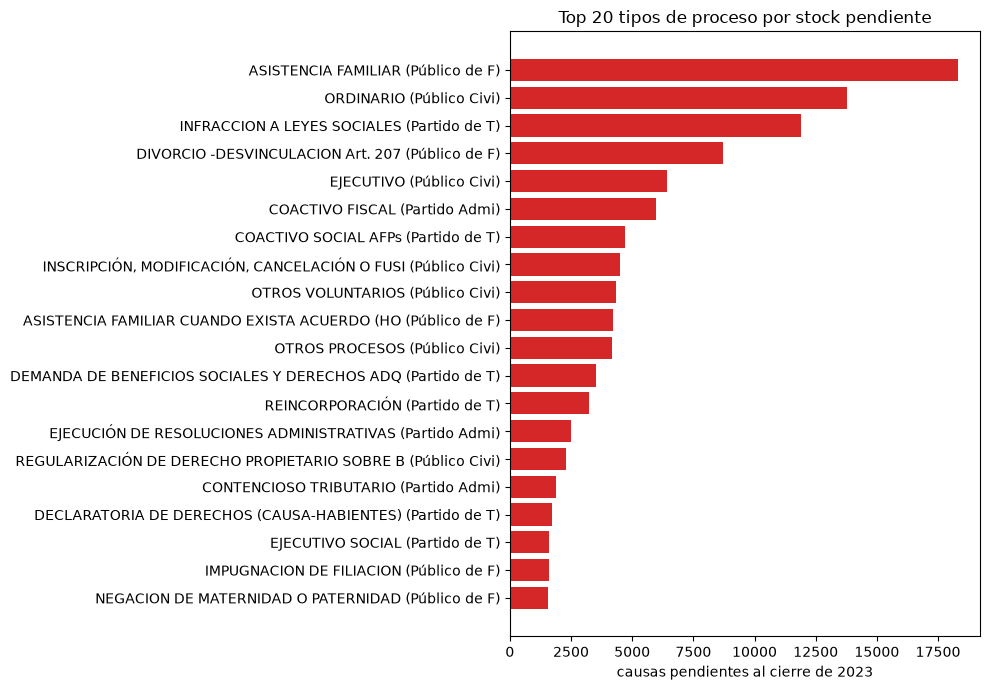

In [7]:
t = top20.iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(t["tipo_proceso"].str[:45] + " (" + t["materia_homologada"].str[:12] + ")", t["pendientes_total"], color="tab:red")
plt.xlabel("causas pendientes al cierre de 2023")
plt.title("Top 20 tipos de proceso por stock pendiente")
plt.tight_layout()
plt.show()

## Mapa de calor: congestión mediana (winsorizada) por departamento y materia

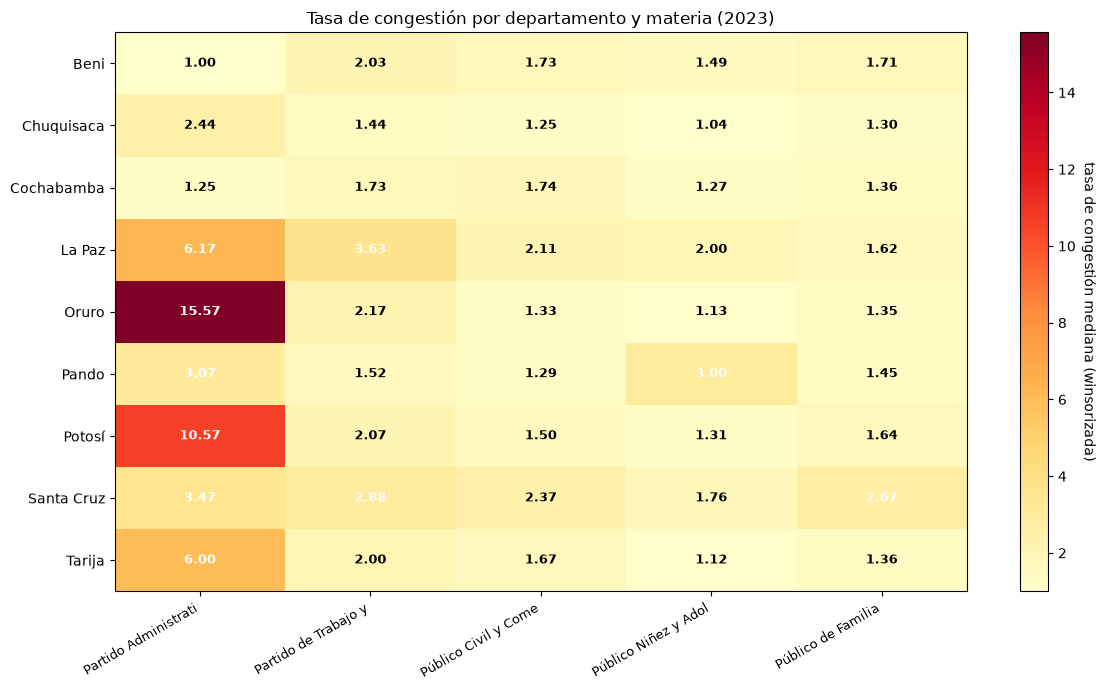

In [8]:
pivot = proc.pivot_table(index="departamento_derivado", columns="materia_homologada", values="tasa_congestion_winsorizada", aggfunc="median")
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels([c[:20] for c in pivot.columns], rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        valor = pivot.values[i, j]
        if not np.isnan(valor):
            if valor > 2.5:
                color = "white"
            else:
                color = "black"
            ax.text(j, i, "{:.2f}".format(valor), ha="center", va="center", color=color, fontsize=9, fontweight="bold")
barra = fig.colorbar(im, ax=ax)
barra.ax.set_ylabel("tasa de congestión mediana (winsorizada)", rotation=-90, va="bottom")
ax.set_title("Tasa de congestión por departamento y materia (2023)")
plt.tight_layout()
plt.savefig(OUT_FIG / "03_heatmap_congestion_departamento_materia.png", dpi=200)
plt.show()

## Personal vs. causas atendidas por departamento (tamaño = congestión, color = tasa de resolución)

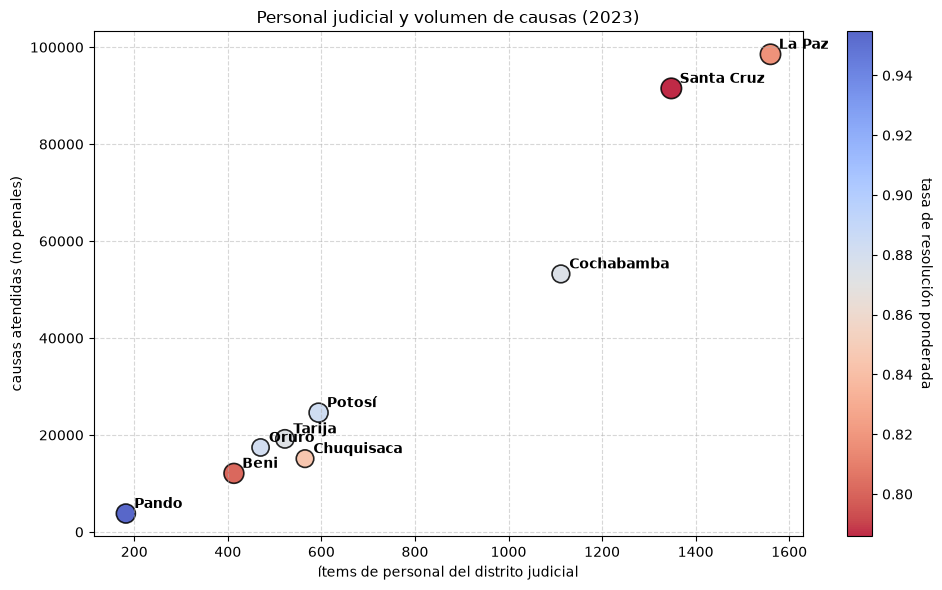

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
puntos = ax.scatter(deptos["personal_items"], deptos["atendidas"], s=deptos["congestion_ponderada"] * 120,
                    c=deptos["cr_ponderado"], cmap="coolwarm_r", alpha=0.85, edgecolors="black", linewidth=1.2)
for i, r in deptos.iterrows():
    ax.annotate(r["departamento_derivado"], (r["personal_items"], r["atendidas"]), xytext=(6, 4), textcoords="offset points", fontweight="bold")
ax.set_xlabel("ítems de personal del distrito judicial")
ax.set_ylabel("causas atendidas (no penales)")
ax.grid(True, linestyle="--", alpha=0.5)
barra = plt.colorbar(puntos, ax=ax)
barra.ax.set_ylabel("tasa de resolución ponderada", rotation=-90, va="bottom")
ax.set_title("Personal judicial y volumen de causas (2023)")
plt.tight_layout()
plt.savefig(OUT_FIG / "04_dispersion_recursos_vs_resolucion.png", dpi=200)
plt.show()

## Capitales vs. provincias en una imagen

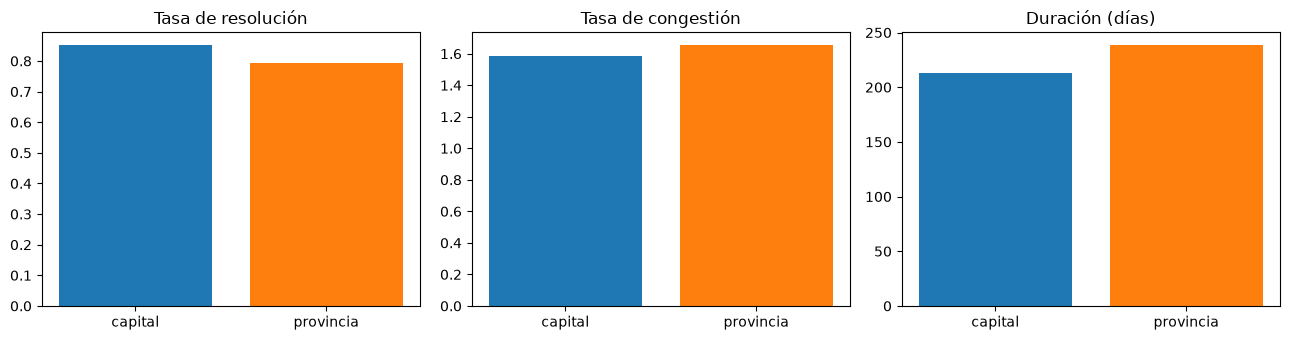

In [10]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 3.5))
indicadores = [("cr_ponderado", "Tasa de resolución"), ("congestion_ponderada", "Tasa de congestión"), ("duracion_dias_ponderada", "Duración (días)")]
for k in range(3):
    col, titulo = indicadores[k]
    ejes[k].bar(ambitos["ambito"], ambitos[col], color=["tab:blue", "tab:orange"])
    ejes[k].set_title(titulo)
plt.tight_layout()
plt.savefig(OUT_FIG / "05_capital_vs_provincia.png", dpi=150)
plt.show()